# V2 — 2D U-Net Evaluation

This notebook evaluates the V2 baseline for multimodal 3D brain tumor MRI segmentation.


In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd().parent

sys.path.append(
    str(PROJECT_ROOT / "src")
)

from v2_2d_unet_model.dataset import BraTSSliceDataset
from v2_2d_unet_model.unet import UNet

# 1. Paths & Device

In [ ]:
VAL_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "v2"
    / "val"
)

CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "models"
    / "v2"
    / "best.pt"
)

print("Project root:", PROJECT_ROOT)
print("Validation directory:", VAL_DIR)
print("Checkpoint:", CHECKPOINT_PATH)

print()
print("Validation directory exists:", VAL_DIR.exists())
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

# Device

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print()
print("Device:", device)

Project root: /Users/abhra/Downloads/AI-ML/Resume/BraTS
Validation directory: /Users/abhra/Downloads/AI-ML/Resume/BraTS/data/processed/v2/val
Checkpoint: /Users/abhra/Downloads/AI-ML/Resume/BraTS/models/v2/best.pt

Validation directory exists: True
Checkpoint exists: True

Device: mps


# 2. Load Validation Dataset

In [ ]:
val_dataset = BraTSSliceDataset(
    VAL_DIR
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("Validation samples:", len(val_dataset))
print("Validation batches:", len(val_loader))

Loading 4 shards from /Users/abhra/Downloads/AI-ML/Resume/BraTS/data/processed/v2/val
  Loading shard_000.npz
  Loading shard_001.npz
  Loading shard_002.npz
  Loading shard_003.npz
Loaded 4000 samples
Images memory: 0.98 GB
Masks memory: 0.24 GB
Validation samples: 4000
Validation batches: 500


# 3. Load Best V2 Model

In [ ]:
model = UNet(
    in_channels=4,
    out_channels=1
).to(device)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation Dice during training:", checkpoint["val_dice"])
print("Validation IoU during training:", checkpoint["val_iou"])
print("Model device:", device)

Checkpoint epoch: 10
Validation Dice during training: 0.8239625466167927
Validation IoU during training: 0.7918927589654923
Model device: mps


# 4. Inference Sanity Check

In [ ]:
images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = model(images)

probabilities = torch.sigmoid(logits)

predictions = (
    probabilities >= 0.5
).float()

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Logits shape:", logits.shape)
print("Probabilities shape:", probabilities.shape)
print("Predictions shape:", predictions.shape)

print()
print("Probability range:")
print(
    probabilities.min().item(),
    "→",
    probabilities.max().item()
)

print()
print("Prediction values:")
print(predictions.unique())


Images shape: torch.Size([8, 4, 128, 128])
Masks shape: torch.Size([8, 128, 128])
Logits shape: torch.Size([8, 1, 128, 128])
Probabilities shape: torch.Size([8, 1, 128, 128])
Predictions shape: torch.Size([8, 1, 128, 128])

Probability range:
2.330674542250222e-10 → 0.9999992847442627

Prediction values:
tensor([0., 1.], device='mps:0')


# 5. Full Validation Evaluation

In [ ]:
total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

all_dice = []
tumor_dice = []

tumor_slices = 0
empty_slices = 0


model.eval()

with torch.no_grad():

    for batch_idx, (images, masks) in enumerate(
        val_loader
    ):

        images = images.to(device)
        masks = masks.to(device)

        # Add channel dimension
        masks_channel = masks.unsqueeze(1)

        # Prediction

        logits = model(images)

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= 0.5
        ).float()

        # Flatten per sample

        pred_flat = predictions.flatten(1)
        mask_flat = masks_channel.flatten(1)

        # Dice per slice

        intersection = (
            pred_flat * mask_flat
        ).sum(dim=1)

        pred_sum = pred_flat.sum(dim=1)
        mask_sum = mask_flat.sum(dim=1)

        dice = (
            2 * intersection + 1e-6
        ) / (
            pred_sum
            + mask_sum
            + 1e-6
        )

        all_dice.extend(
            dice.cpu().numpy()
        )

        # Tumor vs empty slices

        has_tumor = (
            mask_sum > 0
        )

        tumor_slices += (
            has_tumor.sum().item()
        )

        empty_slices += (
            (~has_tumor).sum().item()
        )

        if has_tumor.any():

            tumor_dice.extend(
                dice[has_tumor]
                .cpu()
                .numpy()
            )

        # Confusion matrix

        total_tp += (
            (
                (pred_flat == 1)
                & (mask_flat == 1)
            )
            .sum()
            .item()
        )

        total_fp += (
            (
                (pred_flat == 1)
                & (mask_flat == 0)
            )
            .sum()
            .item()
        )

        total_fn += (
            (
                (pred_flat == 0)
                & (mask_flat == 1)
            )
            .sum()
            .item()
        )

        total_tn += (
            (
                (pred_flat == 0)
                & (mask_flat == 0)
            )
            .sum()
            .item()
        )


# ==================================================
# Metrics
# ==================================================

overall_dice = (
    2 * total_tp
    /
    (
        2 * total_tp
        + total_fp
        + total_fn
        + 1e-8
    )
)

iou = (
    total_tp
    /
    (
        total_tp
        + total_fp
        + total_fn
        + 1e-8
    )
)

precision = (
    total_tp
    /
    (
        total_tp
        + total_fp
        + 1e-8
    )
)

recall = (
    total_tp
    /
    (
        total_tp
        + total_fn
        + 1e-8
    )
)

specificity = (
    total_tn
    /
    (
        total_tn
        + total_fp
        + 1e-8
    )
)

mean_slice_dice = np.mean(
    all_dice
)

mean_tumor_dice = np.mean(
    tumor_dice
)


# ==================================================
# Results
# ==================================================

print("=" * 60)
print("V2 FULL VALIDATION RESULTS")
print("=" * 60)

print(
    f"Overall Pixel Dice:   {overall_dice:.4f}"
)

print(
    f"Mean Slice Dice:      {mean_slice_dice:.4f}"
)

print(
    f"Tumor Slice Dice:     {mean_tumor_dice:.4f}"
)

print(
    f"IoU:                  {iou:.4f}"
)

print(
    f"Precision:            {precision:.4f}"
)

print(
    f"Recall:               {recall:.4f}"
)

print(
    f"Specificity:          {specificity:.4f}"
)

print()
print(
    f"Tumor slices:         {tumor_slices}"
)

print(
    f"Empty slices:         {empty_slices}"
)

print()
print("Confusion Matrix")
print("------------------------------")
print("TP:", total_tp)
print("FP:", total_fp)
print("FN:", total_fn)
print("TN:", total_tn)

V2 FULL VALIDATION RESULTS
Overall Pixel Dice:   0.9294
Mean Slice Dice:      0.8240
Tumor Slice Dice:     0.8393
IoU:                  0.8681
Precision:            0.9380
Recall:               0.9209
Specificity:          0.9992

Tumor slices:         1992
Empty slices:         2008

Confusion Matrix
------------------------------
TP: 749345
FP: 49509
FN: 64377
TN: 64672769


# 6. Visualize Validation Predictions

In [ ]:
def get_prediction(index):

    image, mask = val_dataset[index]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)

    probability = torch.sigmoid(logits)[0, 0]

    prediction = (
        probability >= 0.5
    ).float()

    return (
        image.cpu().numpy(),
        mask.cpu().numpy(),
        probability.cpu().numpy(),
        prediction.cpu().numpy()
    )


# Pick a tumor-containing validation slice
sample_index = next(
    i
    for i in range(len(val_dataset))
    if val_dataset[i][1].sum() > 0
)

image, ground_truth, probability, prediction = (
    get_prediction(sample_index)
)

print("Sample index:", sample_index)
print("Image shape:", image.shape)
print("Ground truth shape:", ground_truth.shape)
print("Prediction shape:", prediction.shape)
print("Ground truth pixels:", int(ground_truth.sum()))
print("Predicted pixels:", int(prediction.sum()))

Sample index: 0
Image shape: (4, 128, 128)
Ground truth shape: (128, 128)
Prediction shape: (128, 128)
Ground truth pixels: 23
Predicted pixels: 0


# 7. Find Representative Tumor Slices

In [ ]:
tumor_samples = []

for i in range(len(val_dataset)):

    _, mask = val_dataset[i]

    tumor_pixels = int(mask.sum())

    if tumor_pixels > 0:
        tumor_samples.append(
            (i, tumor_pixels)
        )


tumor_samples = sorted(
    tumor_samples,
    key=lambda x: x[1]
)

print("Tumor-containing slices:", len(tumor_samples))

print("\nSmall tumor slices:")
for item in tumor_samples[:5]:
    print(item)

print("\nMedium tumor slices:")
mid = len(tumor_samples) // 2

for item in tumor_samples[mid-2:mid+3]:
    print(item)

print("\nLarge tumor slices:")
for item in tumor_samples[-5:]:
    print(item)

Tumor-containing slices: 1992

Small tumor slices:
(98, 1)
(205, 1)
(740, 1)
(1146, 1)
(1522, 1)

Medium tumor slices:
(1714, 363)
(2766, 364)
(3226, 364)
(941, 365)
(1615, 365)

Large tumor slices:
(539, 1472)
(2494, 1473)
(979, 1475)
(525, 1493)
(3084, 1512)


# 8. Medium Tumor Visualization

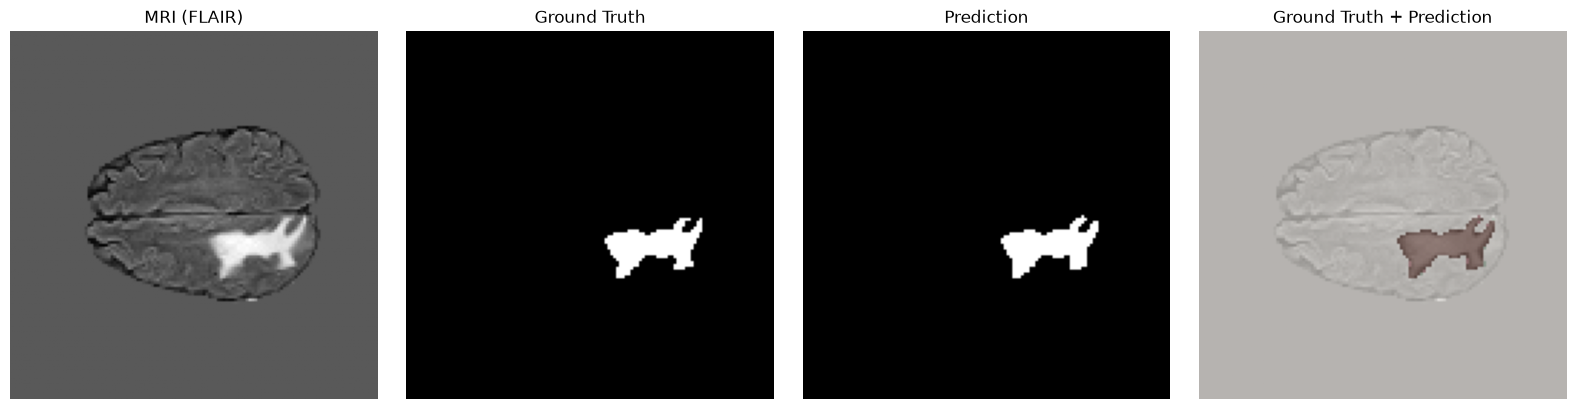

Sample index: 2766
Ground truth pixels: 364
Predicted pixels: 367


In [ ]:
sample_index = 2766

image, ground_truth, probability, prediction = (
    get_prediction(sample_index)
)

# Use the T2-FLAIR channel for visualization.
# Channel order:
# 0 = T1
# 1 = T1ce
# 2 = T2
# 3 = FLAIR

flair = image[3]

fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

# MRI

axes[0].imshow(
    flair,
    cmap="gray"
)

axes[0].set_title("MRI (FLAIR)")
axes[0].axis("off")


# Ground Truth

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title("Ground Truth")
axes[1].axis("off")


# Prediction

axes[2].imshow(
    prediction,
    cmap="gray"
)

axes[2].set_title("Prediction")
axes[2].axis("off")


# Overlay

axes[3].imshow(
    flair,
    cmap="gray"
)

axes[3].imshow(
    ground_truth,
    cmap="Greens",
    alpha=0.35
)

axes[3].imshow(
    prediction,
    cmap="Reds",
    alpha=0.35
)

axes[3].set_title(
    "Ground Truth + Prediction"
)

axes[3].axis("off")


plt.tight_layout()
plt.show()


print("Sample index:", sample_index)
print(
    "Ground truth pixels:",
    int(ground_truth.sum())
)

print(
    "Predicted pixels:",
    int(prediction.sum())
)

# 9. Rank Tumor-Containing Slices by Dice

In [ ]:
tumor_results = []

model.eval()

for i in range(len(val_dataset)):

    image, ground_truth = val_dataset[i]

    # Skip empty slices
    if ground_truth.sum() == 0:
        continue

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_tensor)

    probability = torch.sigmoid(
        logits
    )[0, 0]

    prediction = (
        probability >= 0.5
    ).float().cpu()

    ground_truth = ground_truth.cpu()

    # Dice

    intersection = (
        prediction * ground_truth
    ).sum().item()

    pred_sum = prediction.sum().item()
    gt_sum = ground_truth.sum().item()

    dice = (
        2 * intersection + 1e-6
    ) / (
        pred_sum
        + gt_sum
        + 1e-6
    )

    tumor_results.append({
        "index": i,
        "dice": dice,
        "gt_pixels": gt_sum,
        "pred_pixels": pred_sum
    })


# Sort

tumor_results.sort(
    key=lambda x: x["dice"]
)

print(
    "Tumor-containing slices:",
    len(tumor_results)
)

print("\nWorst 5:")
for result in tumor_results[:5]:
    print(result)

print("\nMedian:")
median_index = len(tumor_results) // 2
print(
    tumor_results[median_index]
)

print("\nBest 5:")
for result in tumor_results[-5:]:
    print(result)

Tumor-containing slices: 1992

Worst 5:
{'index': 2386, 'dice': 3.952569154337671e-09, 'gt_pixels': 183.0, 'pred_pixels': 70.0}
{'index': 2387, 'dice': 5.10204079029571e-09, 'gt_pixels': 132.0, 'pred_pixels': 64.0}
{'index': 2006, 'dice': 8.474576199367998e-09, 'gt_pixels': 1.0, 'pred_pixels': 117.0}
{'index': 409, 'dice': 1.1111110987654323e-08, 'gt_pixels': 90.0, 'pred_pixels': 0.0}
{'index': 71, 'dice': 1.123595492993309e-08, 'gt_pixels': 89.0, 'pred_pixels': 0.0}

Median:
{'index': 540, 'dice': 0.93243243288897, 'gt_pixels': 77.0, 'pred_pixels': 71.0}

Best 5:
{'index': 2303, 'dice': 0.9899607158489914, 'gt_pixels': 1154.0, 'pred_pixels': 1137.0}
{'index': 2133, 'dice': 0.9902152641942497, 'gt_pixels': 772.0, 'pred_pixels': 761.0}
{'index': 3297, 'dice': 0.9905163329870831, 'gt_pixels': 957.0, 'pred_pixels': 941.0}
{'index': 525, 'dice': 0.9909426367021327, 'gt_pixels': 1493.0, 'pred_pixels': 1488.0}
{'index': 2138, 'dice': 0.9935332157592397, 'gt_pixels': 852.0, 'pred_pixels': 849

# 10. Error Analysis Visualization

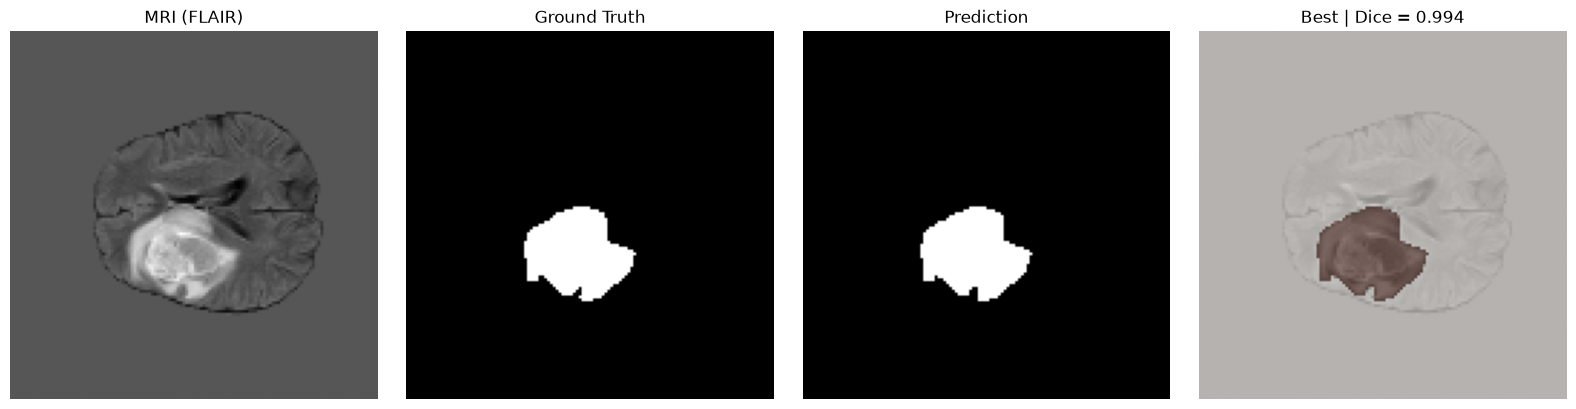

Best
----------------------------------------
Index: 2138
Ground truth pixels: 852
Predicted pixels: 849
Dice: 0.9935


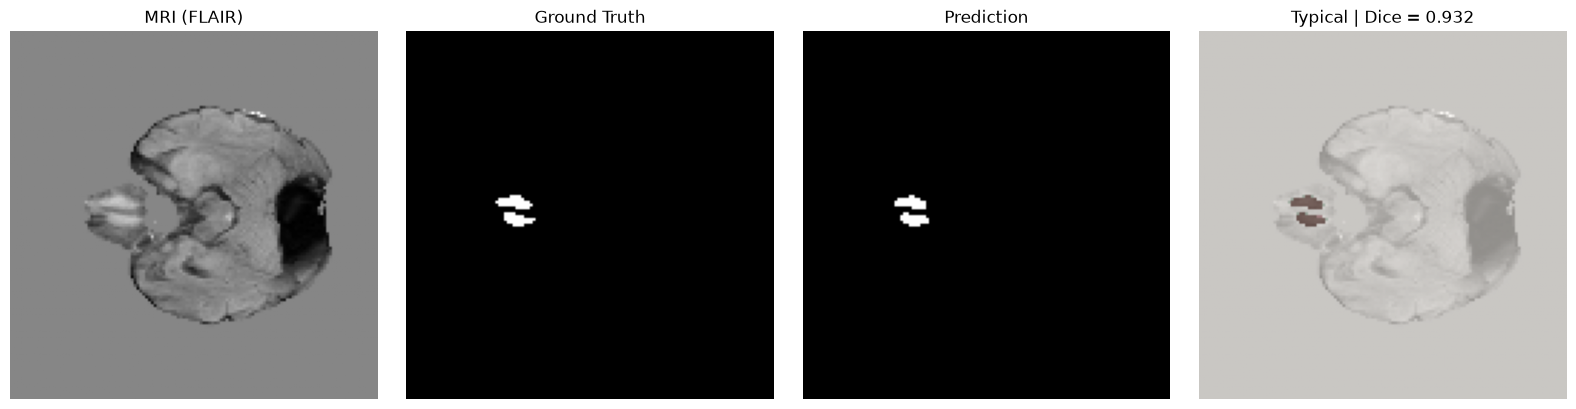

Typical
----------------------------------------
Index: 540
Ground truth pixels: 77
Predicted pixels: 71
Dice: 0.9324


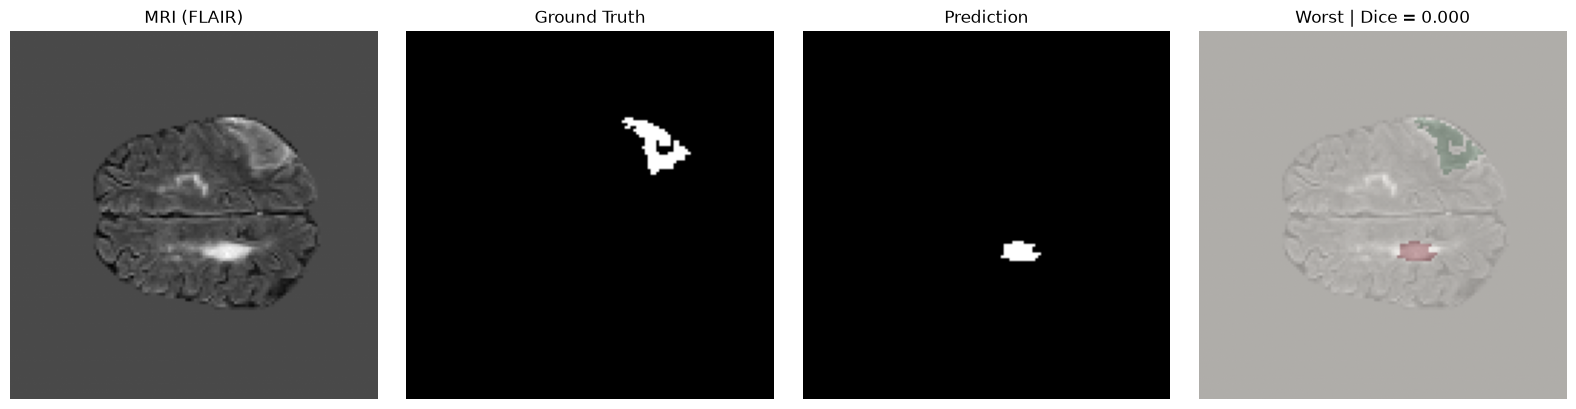

Worst
----------------------------------------
Index: 2386
Ground truth pixels: 183
Predicted pixels: 70
Dice: 0.0000


In [ ]:
selected_cases = {
    "Best": 2138,
    "Typical": 540,
    "Worst": 2386,
}


def visualize_case(
    index,
    title
):

    image, ground_truth, probability, prediction = (
        get_prediction(index)
    )

    flair = image[3]

    # Dice
    intersection = (
        prediction * ground_truth
    ).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        prediction.sum()
        + ground_truth.sum()
        + 1e-6
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    # MRI
    axes[0].imshow(
        flair,
        cmap="gray"
    )

    axes[0].set_title(
        "MRI (FLAIR)"
    )

    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(
        ground_truth,
        cmap="gray"
    )

    axes[1].set_title(
        "Ground Truth"
    )

    axes[1].axis("off")

    # Prediction
    axes[2].imshow(
        prediction,
        cmap="gray"
    )

    axes[2].set_title(
        "Prediction"
    )

    axes[2].axis("off")

    # Overlay
    axes[3].imshow(
        flair,
        cmap="gray"
    )

    axes[3].imshow(
        ground_truth,
        cmap="Greens",
        alpha=0.35
    )

    axes[3].imshow(
        prediction,
        cmap="Reds",
        alpha=0.35
    )

    axes[3].set_title(
        f"{title} | Dice = {dice:.3f}"
    )

    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"{title}")
    print("-" * 40)
    print("Index:", index)
    print(
        "Ground truth pixels:",
        int(ground_truth.sum())
    )
    print(
        "Predicted pixels:",
        int(prediction.sum())
    )
    print(
        "Dice:",
        f"{dice:.4f}"
    )


for title, index in selected_cases.items():

    visualize_case(
        index,
        title
    )

# 11. Final V2 Qualitative Figure

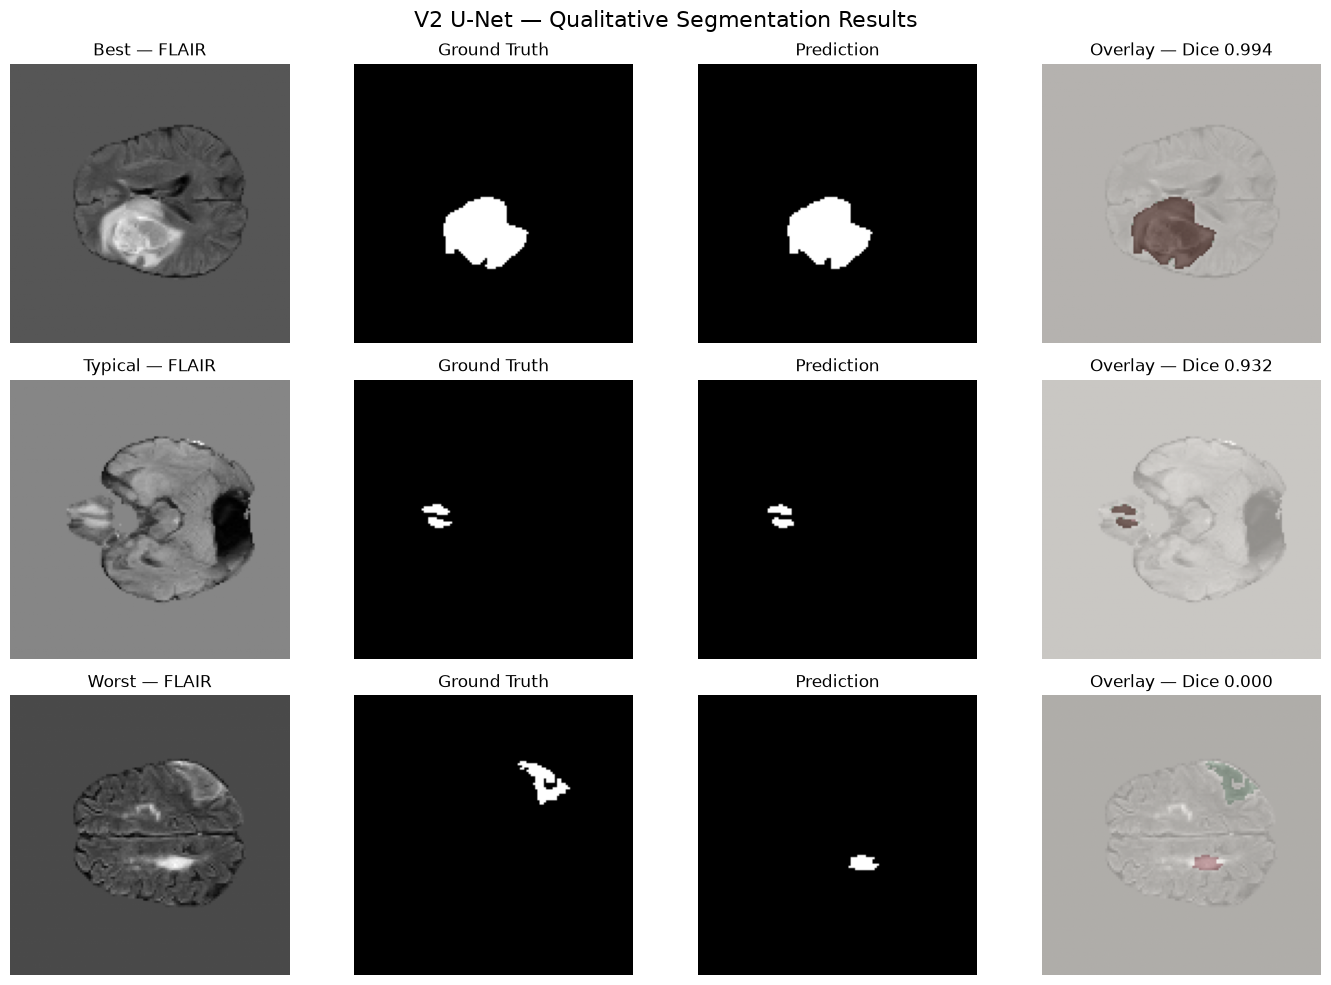

In [ ]:
cases = [
    ("Best", 2138),
    ("Typical", 540),
    ("Worst", 2386),
]

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 10)
)


for row, (case_name, index) in enumerate(cases):

    image, ground_truth, probability, prediction = (
        get_prediction(index)
    )

    flair = image[3]

    # Dice

    intersection = (
        prediction * ground_truth
    ).sum()

    dice = (
        2 * intersection + 1e-6
    ) / (
        prediction.sum()
        + ground_truth.sum()
        + 1e-6
    )

    # FLAIR

    axes[row, 0].imshow(
        flair,
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"{case_name} — FLAIR"
    )

    # Ground Truth

    axes[row, 1].imshow(
        ground_truth,
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Ground Truth"
    )

    # Prediction

    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )

    axes[row, 2].set_title(
        "Prediction"
    )

    # Overlay

    axes[row, 3].imshow(
        flair,
        cmap="gray"
    )

    axes[row, 3].imshow(
        ground_truth,
        cmap="Greens",
        alpha=0.35
    )

    axes[row, 3].imshow(
        prediction,
        cmap="Reds",
        alpha=0.35
    )

    axes[row, 3].set_title(
        f"Overlay — Dice {dice:.3f}"
    )

    # Formatting

    for col in range(4):

        axes[row, col].axis("off")


plt.suptitle(
    "V2 U-Net — Qualitative Segmentation Results",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [13]:
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "v2"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    RESULTS_DIR
    / "v2_qualitative_results.png",
    dpi=200,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>